In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv(r"C:\Users\Administrator\Desktop\Machine Learning Engineer\Test_data.csv")
df['Income']= df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['Loan_ID','CoapplicantIncome', 'ApplicantIncome'], axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
0,Male,No,0,Graduate,No,NaN,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0


In [3]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols]= df[bool_cols].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            601 non-null    object 
 1   Married           611 non-null    object 
 2   Dependents        599 non-null    object 
 3   Education         614 non-null    object 
 4   Self_Employed     582 non-null    object 
 5   LoanAmount        592 non-null    float64
 6   Loan_Amount_Term  600 non-null    float64
 7   Credit_History    564 non-null    float64
 8   Property_Area     614 non-null    object 
 9   Loan_Status       614 non-null    object 
 10  Income            614 non-null    float64
dtypes: float64(4), object(7)
memory usage: 52.9+ KB


In [4]:
df1= pd.get_dummies(df, drop_first="True")

In [5]:
df1.corr()['Loan_Status_Y'].sort_values(ascending=False)

Loan_Status_Y              1.000000
Credit_History             0.561678
Property_Area_Semiurban    0.136540
Married_Yes                0.084281
Dependents_2               0.062384
Gender_Male                0.025407
Self_Employed_Yes         -0.003700
Loan_Amount_Term          -0.021268
Dependents_3+             -0.026123
Income                    -0.031271
LoanAmount                -0.037318
Dependents_1              -0.038740
Property_Area_Urban       -0.043621
Education_Not Graduate    -0.085884
Name: Loan_Status_Y, dtype: float64

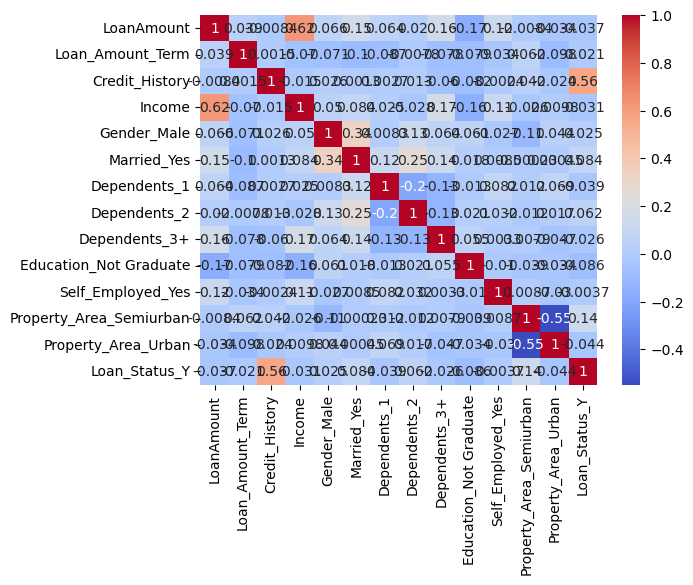

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.show()

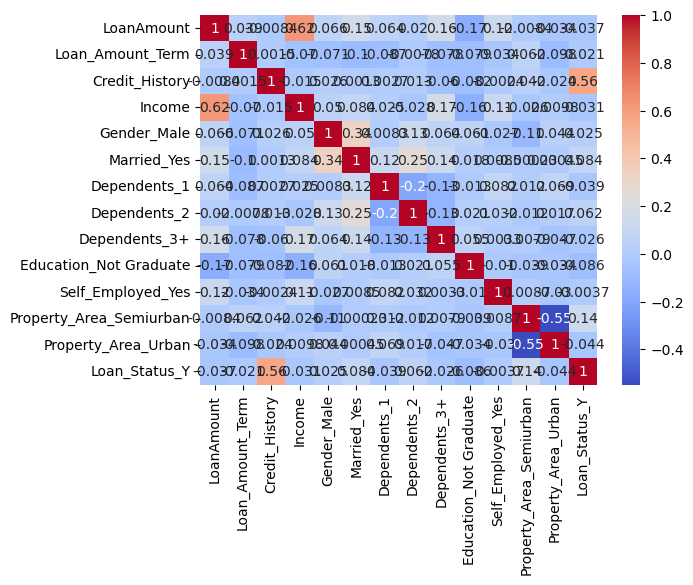

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.show()

In [7]:
from sklearn.tree import DecisionTreeClassifier

X = df1.drop('Loan_Status_Y', axis=1)
y = df1['Loan_Status_Y']

model = DecisionTreeClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)


Credit_History             0.292201
Income                     0.278841
LoanAmount                 0.222579
Loan_Amount_Term           0.046823
Property_Area_Semiurban    0.029008
Education_Not Graduate     0.025685
Property_Area_Urban        0.022987
Self_Employed_Yes          0.020291
Married_Yes                0.019889
Dependents_2               0.014422
Gender_Male                0.010988
Dependents_1               0.010230
Dependents_3+              0.006055
dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

x= df[['Income','Credit_History','Self_Employed']]
y=df['Loan_Status'].map({'N':0, 'Y':1})

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=100, stratify=y)

num_cols= x.select_dtypes(include='float64').columns
cat_cols= x.select_dtypes(include='object').columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced'))
])

pipeline.fit(x_train, y_train)
y_pred= pipeline.predict(x_test)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8130081300813008
Precision: 0.7924528301886793
Recall: 0.9882352941176471
F1 Score: 0.8795811518324608
Confusion Matrix:
 [[16 22]
 [ 1 84]]


In [10]:
from sklearn.model_selection import cross_val_score
score= cross_val_score(pipeline, x_train, y_train, cv=5, scoring='f1')
print('cross_val_score:', score)
print('Mean:', score.mean())

cross_val_score: [0.85350318 0.90540541 0.875      0.84210526 0.86666667]
Mean: 0.8685361039886687


In [11]:
model = pipeline.named_steps['model']
print(model.coef_)
print(model.intercept_)

[[0.01238706 1.23486338 0.00805043 0.00669671]]
[0.01604472]


In [12]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')
grid.fit(x_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__C': 0.01, 'model__solver': 'liblinear'}
0.8731365702200957


In [13]:
grid.best_estimator_.score(x_test, y_test)

0.8130081300813008

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Features and target
X = df.drop(['Loan_Status', 'LoanAmount', 'Loan_Amount_Term'], axis=1)
# X = df.drop('Loan_Status', axis=1)
Y = df['Loan_Status'].map({'N':0, 'Y':1})

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=y
)

# Column groups
num_cols= X.select_dtypes(include='float64').columns
cat_cols= X.select_dtypes(include='object').columns

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
])

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3))
])

pipeline_tree.fit(X_train, Y_train)
Y_pred= pipeline_tree.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.8455284552845529
Precision: 0.84375
Recall: 0.9529411764705882
F1 Score: 0.8950276243093923
Confusion Matrix:
 [[23 15]
 [ 4 81]]


In [16]:
param_grid = {
    'model__max_depth': [3, 5, 10],
    'model__criterion': ['gini', 'entropy'],
    'model__min_samples_split': [2, 5, 10]
}

grid1 = GridSearchCV(
    pipeline_tree,
    param_grid,
    cv=5,
    scoring='f1'
)

grid1.fit(X_train, Y_train)

,estimator,Pipeline(step...ax_depth=3))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [17]:
print(grid1.best_params_)
print(grid1.best_score_)

{'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 10}
0.8617074230443922


In [18]:
grid1.best_estimator_.score(X_test, Y_test)

0.8536585365853658

In [19]:
df_xgboost= pd.get_dummies(df, drop_first=True)

In [20]:
bool_cols = df_xgboost.select_dtypes(include='bool').columns
df_xgboost[bool_cols] = df_xgboost[bool_cols].astype(int)
df_xgboost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LoanAmount               592 non-null    float64
 1   Loan_Amount_Term         600 non-null    float64
 2   Credit_History           564 non-null    float64
 3   Income                   614 non-null    float64
 4   Gender_Male              614 non-null    int64  
 5   Married_Yes              614 non-null    int64  
 6   Dependents_1             614 non-null    int64  
 7   Dependents_2             614 non-null    int64  
 8   Dependents_3+            614 non-null    int64  
 9   Education_Not Graduate   614 non-null    int64  
 10  Self_Employed_Yes        614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    int64  
 12  Property_Area_Urban      614 non-null    int64  
 13  Loan_Status_Y            614 non-null    int64  
dtypes: float64(4), int64(10)
m

In [21]:
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Features and target
a= df_xgboost.drop(['Loan_Status_Y', 'LoanAmount', 'Loan_Amount_Term'], axis=1)
b = df_xgboost['Loan_Status_Y']

# Split
X_train, X_test, y_train, y_test = train_test_split(a, b, test_size=0.2, random_state=42, stratify=b)

# Model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8699186991869918
              precision    recall  f1-score   support

           0       0.96      0.61      0.74        38
           1       0.85      0.99      0.91        85

    accuracy                           0.87       123
   macro avg       0.90      0.80      0.83       123
weighted avg       0.88      0.87      0.86       123



In [23]:
a= df_xgboost.drop(['Loan_Status_Y', 'LoanAmount', 'Loan_Amount_Term'], axis=1)
b = df_xgboost['Loan_Status_Y']

# Split data
X_train, X_test, y_train, y_test = train_test_split(a,b,test_size=0.2,random_state=42,stratify=b)

# Base model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=2.1,
    random_state=42
)

# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best score
print("\nBest CV Score:")
print(grid_search.best_score_)

# Best model
best_model = grid_search.best_estimator_

# Predictions
pred = best_model.predict(X_test)

# Accuracy
print("\nTest Accuracy:")
print(f1_score(y_test, pred))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.7}

Best CV Score:
0.870270435446906

Test Accuracy:
0.8983957219251337
